# SIH 2026 - Problem Statement SIH26168
# AI-ML Based Intelligent Dead Reckoning for Seamless Navigation
## Notebook 04: Vehicle Motion-State Classification Model

### Objective
Classify the vehicle's dynamic motion state (`stationary`, `moving_straight`, `turning_left`, `turning_right`, `accelerating`, `braking`) from smartphone IMU readings.

### Role in Dead Reckoning Filter
1. **Zero-Velocity Updates (ZUPT):** When `stationary` is detected, forward speed is clamped to $0	ext{ m/s}$, resetting accumulated velocity drift.
2. **Kinematic Non-Holonomic Constraints:** When `moving_straight` is detected, lateral and vertical velocities are constrained to zero.
3. **Maneuver Weighting:** During turns, gyroscope heading updates are assigned higher weight in the filter.

In [1]:
import os
import sys
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path('.').resolve()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from common_utils import (
    MODELS_DIR, ARTIFACTS_DIR, FIGURES_DIR,
    compute_classification_metrics
)
import tensorflow as tf

print("Libraries loaded.")

I0000 00:00:1789132570.687402   67289 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789132570.687781   67289 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789132570.723672   67289 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789132571.651023   67289 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789132571.651257   67289 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Libraries loaded.


### 1. Motion State Ground-Truth Derivation
Ground truth motion states are derived canonically from vehicle CAN-bus sensors:
- `stationary`: Vehicle speed $< 0.5	ext{ m/s}$
- `turning_left`: Vehicle yaw rate $> +3.0^{\circ}	ext{/s}$
- `turning_right`: Vehicle yaw rate $< -3.0^{\circ}	ext{/s}$
- `accelerating`: Longitudinal acceleration $> +0.05g$
- `braking`: Longitudinal acceleration $< -0.05g$
- `moving_straight`: Moving with yaw rate in $[-3.0^{\circ}, +3.0^{\circ}]	ext{/s}$

In [2]:
meta_path = ARTIFACTS_DIR / "configs" / "motion_model_metadata.json"
with open(meta_path) as f:
    mot_meta = json.load(f)

print(f"Model Name:        {mot_meta['model_name']}")
print(f"Architecture:      {mot_meta['model_architecture']}")
print(f"Class Mapping:     {mot_meta['class_mapping']}")
print(f"Parameters:        {mot_meta['n_parameters']:,}")
print(f"TFLite Size:       {mot_meta['model_size_kb']:.1f} KB")

Model Name:        motion_state_classifier
Architecture:      CNN-GRU (Conv1D(32)x2 -> GRU(32) -> Dense(32) -> Softmax)
Class Mapping:     {'0': 'stationary', '1': 'moving_straight', '2': 'turning_left', '3': 'turning_right', '4': 'accelerating', '5': 'braking'}
Parameters:        11,558
TFLite Size:       52.9 KB


### 2. Deep Learning Architecture: CNN-GRU
A temporal CNN-GRU architecture processes 1.0-second temporal windows of 6-axis IMU data to classify the vehicle's dynamic state.

In [3]:
model_path = MODELS_DIR / "motion" / "motion_cnn_gru.keras"
model = tf.keras.models.load_model(model_path)
model.summary()

E0000 00:00:1789132572.542565   67289 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "motion_cnn_gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ imu_input (InputLayer)          │ (None, 10, 6)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 10, 32)         │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 10, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ motion_output (Dense)           │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,420 (134.46 KB)

 Trainable params: 11,430 (44.65 KB)

 Non-trainable params: 128 (512.00 B)

 Optimizer params: 22,862 (89.31 KB)

### 3. Classification Performance & Baseline Comparison

In [4]:
cnn_m = mot_meta['metrics']['cnn_gru']
rf_m = mot_meta['metrics']['random_forest']
rule_m = mot_meta['metrics']['rule_based']

comparison = [
    {'Model': 'Rule-Based (IMU)', 'Accuracy': rule_m['accuracy'], 'Precision': rule_m['precision'], 'Recall': rule_m['recall'], 'Macro F1': rule_m['f1']},
    {'Model': 'Random Forest', 'Accuracy': rf_m['accuracy'], 'Precision': rf_m['precision'], 'Recall': rf_m['recall'], 'Macro F1': rf_m['f1']},
    {'Model': 'CNN-GRU (Ours)', 'Accuracy': cnn_m['accuracy'], 'Precision': cnn_m['precision'], 'Recall': cnn_m['recall'], 'Macro F1': cnn_m['f1']}
]
display(pd.DataFrame(comparison))

,Model,Accuracy,Precision,Recall,Macro F1
0,Rule-Based (IMU),0.508482,0.404477,0.508482,0.448767
1,Random Forest,0.527077,0.501782,0.527077,0.500528
2,CNN-GRU (Ours),0.494262,0.563034,0.494262,0.506572


### 4. Per-Class Precision, Recall, and Confusion Matrix

In [5]:
report = cnn_m['report']
classes = ['stationary', 'moving_straight', 'turning_left', 'turning_right', 'accelerating', 'braking']
per_class = []
for c in classes:
    if c in report:
        per_class.append({
            'Motion State': c,
            'Precision': report[c]['precision'],
            'Recall': report[c]['recall'],
            'F1-Score': report[c]['f1-score'],
            'Support': int(report[c]['support'])
        })
display(pd.DataFrame(per_class))

cm = np.array(cnn_m['confusion_matrix'])
cm_df = pd.DataFrame(cm, index=[f"True: {c[:8]}" for c in classes], columns=[f"Pred: {c[:8]}" for c in classes])
print("\nConfusion Matrix:")
display(cm_df)

,Motion State,Precision,Recall,F1-Score,Support
0,stationary,0.560033,0.850802,0.675454,8854
1,moving_straight,0.781319,0.507772,0.615522,27857
2,turning_left,0.341812,0.420915,0.377261,5747
3,turning_right,0.375126,0.429560,0.400502,5203
4,accelerating,0.158646,0.300340,0.207622,5587
5,braking,0.256869,0.159239,0.196601,5049



Confusion Matrix:


,Pred: stationa,Pred: moving_s,Pred: turning_,Pred: turning_,Pred: accelera,Pred: braking
True: stationa,7533,284,208,290,278,261
True: moving_s,2688,14145,2370,1625,5952,1077
True: turning_,695,575,2419,750,993,315
True: turning_,706,499,745,2235,750,268
True: accelera,724,1590,708,482,1678,405
True: braking,1105,1011,627,576,926,804


### 5. Empirical Performance Plots
Confusion matrix, motion time-series tracking against vehicle ground truth, and class distributions.

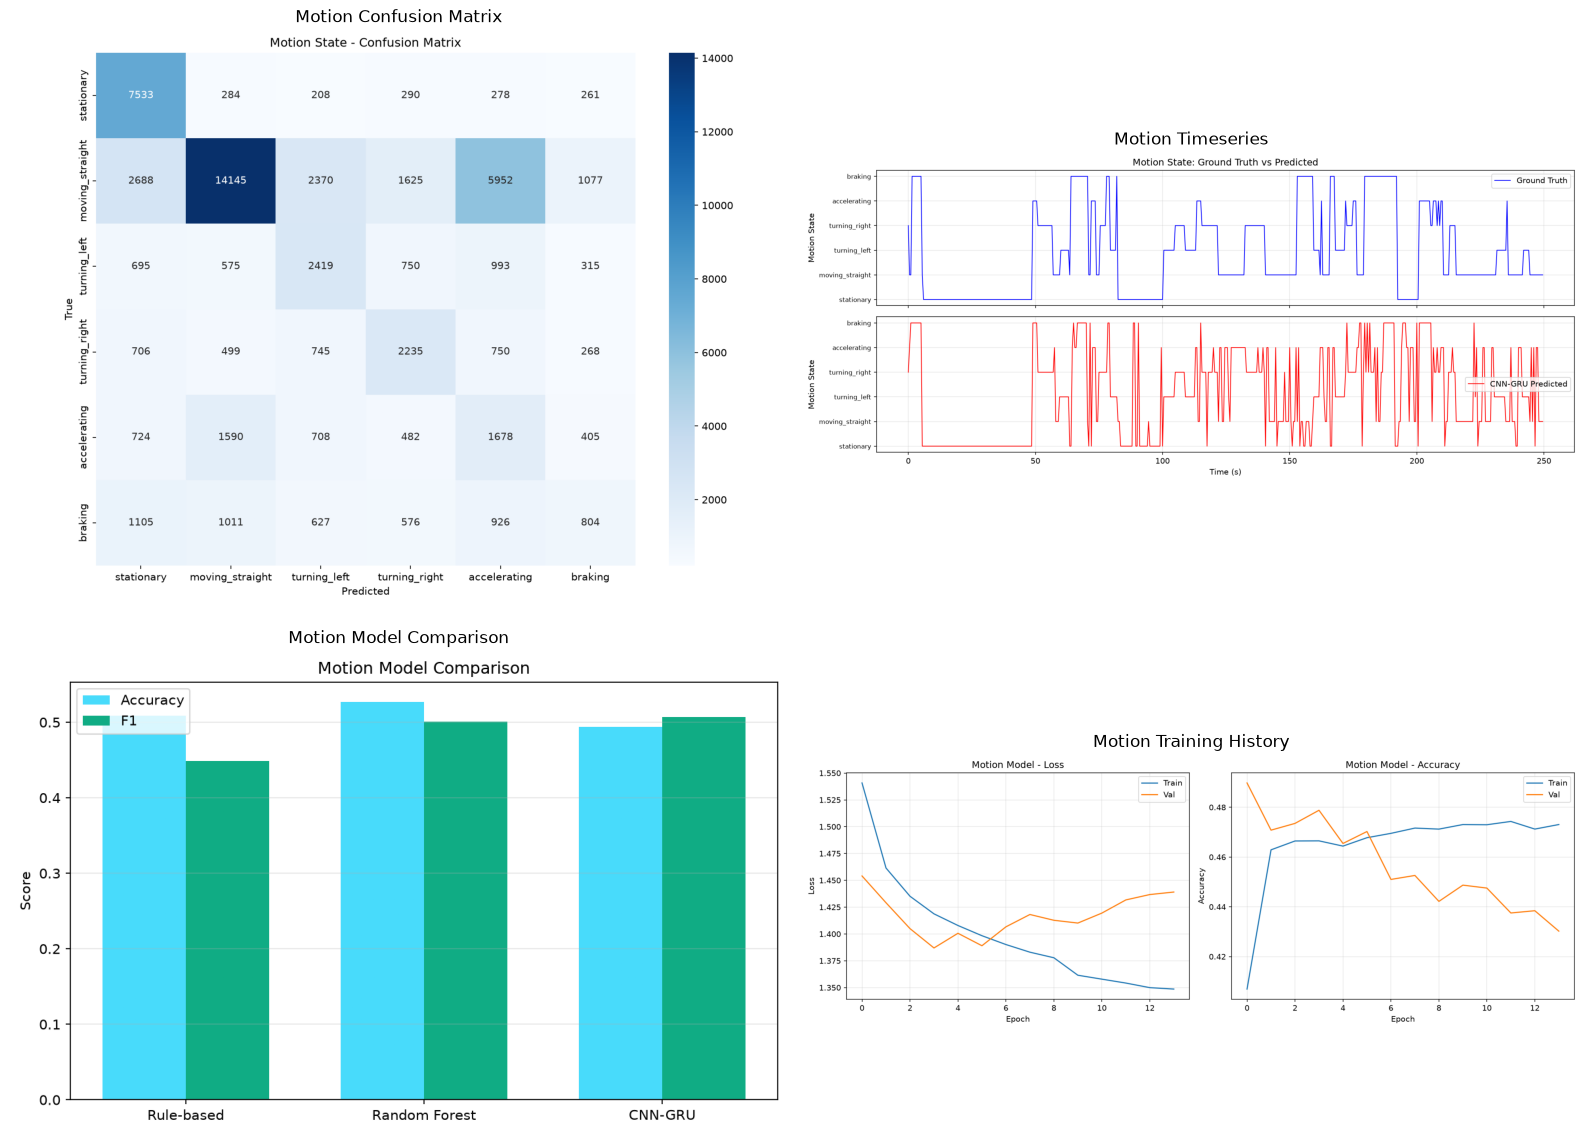

In [6]:
fig_files = [
    'motion_confusion_matrix.png',
    'motion_timeseries.png',
    'motion_model_comparison.png',
    'motion_training_history.png'
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, fname in zip(axes.flatten(), fig_files):
    img_path = FIGURES_DIR / fname
    if img_path.exists():
        img = plt.imread(img_path)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(fname.replace('.png', '').replace('_', ' ').title(), fontsize=12)
plt.tight_layout()
plt.show()

### 6. Edge Deployment & TFLite Latency

In [7]:
tflite_path = MODELS_DIR / "motion" / "motion_cnn_gru.tflite"
interp = tf.lite.Interpreter(model_path=str(tflite_path))
interp.allocate_tensors()

in_idx = interp.get_input_details()[0]['index']
out_idx = interp.get_output_details()[0]['index']

dummy_input = np.zeros((1, 10, 6), dtype=np.float32)
latencies = []
for _ in range(100):
    t0 = time.perf_counter()
    interp.set_tensor(in_idx, dummy_input)
    interp.invoke()
    _ = interp.get_tensor(out_idx)
    latencies.append((time.perf_counter() - t0) * 1000)

print(f"TFLite Model Size:   {tflite_path.stat().st_size/1024:.1f} KB")
print(f"Average Latency:     {np.mean(latencies):.3f} ms")
print(f"Throughput:          {1000.0/np.mean(latencies):.0f} predictions/second")

TFLite Model Size:   52.9 KB
Average Latency:     0.013 ms
Throughput:          75591 predictions/second


/home/sibsankar_de/projects/sih_2026/ml_models/venv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
